 ## Step 1 : Load Data

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"ercentt","key":"4594decf57a1912b478a0e2789ab3deb"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!pip install kaggle -q

In [7]:
!kaggle datasets download -d brycecf/give-me-some-credit-dataset

Dataset URL: https://www.kaggle.com/datasets/brycecf/give-me-some-credit-dataset
License(s): unknown
100% 5.16M/5.16M [00:00<00:00, 126MB/s]



In [8]:
!unzip -o give-me-some-credit-dataset.zip -d give_me_credit_data

Archive:  give-me-some-credit-dataset.zip
  inflating: give_me_credit_data/Data Dictionary.xls  
  inflating: give_me_credit_data/cs-test.csv  
  inflating: give_me_credit_data/cs-training.csv  
  inflating: give_me_credit_data/sampleEntry.csv  


In [9]:
import os
print(os.listdir('give_me_credit_data'))

['sampleEntry.csv', 'Data Dictionary.xls', 'cs-test.csv', 'cs-training.csv']


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,confusion_matrix, precision_recall_curve, f1_score)
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import shap
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

In [12]:
df = pd.read_csv("give_me_credit_data/cs-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [13]:
df.shape

(150000, 12)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [15]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)

,proportion
SeriousDlqin2yrs,
0,0.93316
1,0.06684


 ## Step 2: Exploratory Data Analysis (EDA)

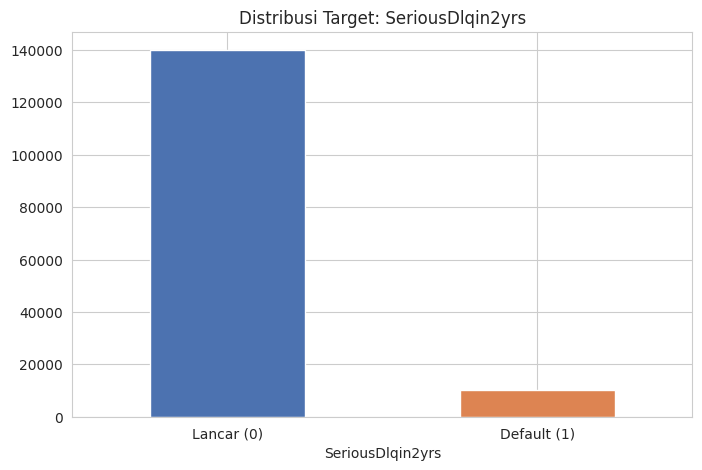

Persentase default: 6.68%


In [17]:
ax = df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
ax.set_title('Distribusi Target: SeriousDlqin2yrs')
ax.set_xticklabels(['Lancar (0)', 'Default (1)'], rotation=0)
plt.show()
print(f"Persentase default: {df['SeriousDlqin2yrs'].mean()*100:.2f}%")

In [18]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
MonthlyIncome,29731,19.820667
NumberOfDependents,3924,2.616000


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


In [22]:
print("Jumlah baris dengan age < 18:", (df['age'] < 18).sum())
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate']:
    print(f"{col} -> value counts tertinggi:")
    print(df[col].value_counts().sort_index(ascending=False).head(3))
    print()


Jumlah baris dengan age < 18: 1
NumberOfTime30-59DaysPastDueNotWorse -> value counts tertinggi:
NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
13      1
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse -> value counts tertinggi:
NumberOfTime60-89DaysPastDueNotWorse
98    264
96      5
11      1
Name: count, dtype: int64

NumberOfTimes90DaysLate -> value counts tertinggi:
NumberOfTimes90DaysLate
98    264
96      5
17      1
Name: count, dtype: int64



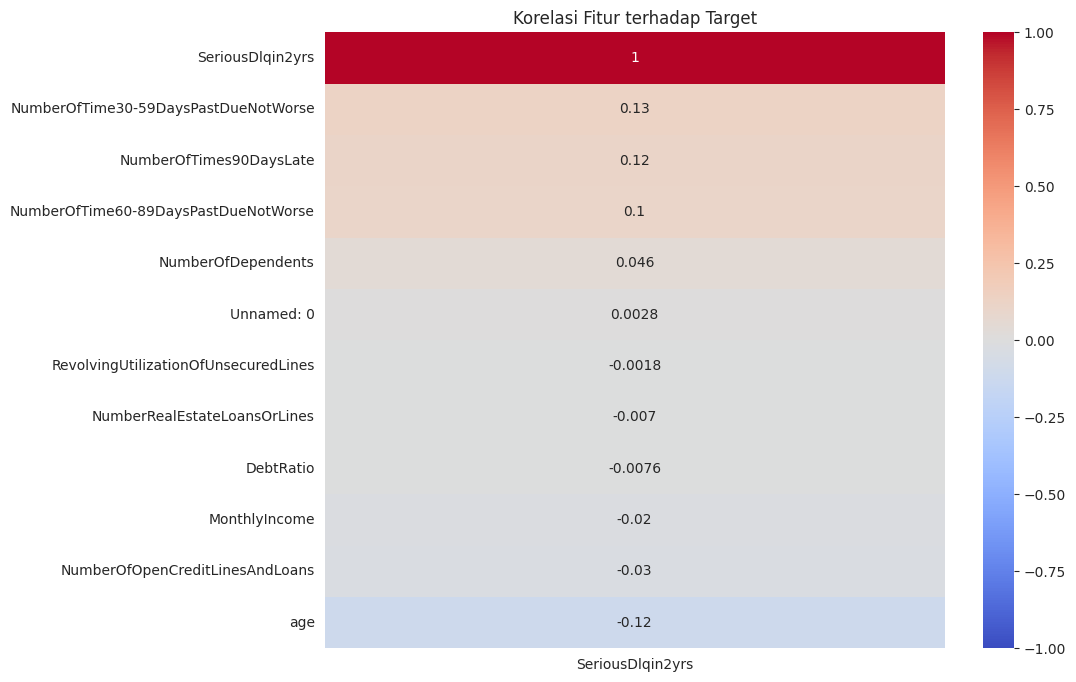

In [23]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr[['SeriousDlqin2yrs']].sort_values('SeriousDlqin2yrs', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Fitur terhadap Target')
plt.show()

## Step 3: Data Cleaning

In [24]:
df_clean = df.copy()
# 1) Fix anomali umur: age = 0 -> ganti ke median age
median_age = df_clean.loc[df_clean['age'] > 0, 'age'].median()
df_clean.loc[df_clean['age'] < 18, 'age'] = median_age
# 2) Fix anomali NumberOfTime...  (nilai 96/98 itu data entry error, biasanya di-cap)
past_due_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
                 'NumberOfTime60-89DaysPastDueNotWorse',
                 'NumberOfTimes90DaysLate']
for col in past_due_cols:
    cap_value = df_clean[df_clean[col] < 90][col].max()
    df_clean.loc[df_clean[col] >= 90, col] = cap_value
# 3) Imputasi MonthlyIncome pake median
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(df_clean['MonthlyIncome'].median())
# 4) Imputasi NumberOfDependents pake modus (biasanya 0)
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(
    df_clean['NumberOfDependents'].mode()[0]
)
# 5) Cap RevolvingUtilizationOfUnsecuredLines yang harusnya rasio tapi ada yang > 1 secara ekstrem
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
print("Missing values setelah cleaning:")
print(df_clean.isnull().sum().sum())


Missing values setelah cleaning:
0


## Step 4: Feature Engineering


In [25]:
df_fe = df_clean.copy()
# Total berapa kali telat bayar (gabungan 3 kolom past due)
df_fe['TotalPastDue'] = (
    df_fe['NumberOfTime30-59DaysPastDueNotWorse']
    + df_fe['NumberOfTime60-89DaysPastDueNotWorse']
    + df_fe['NumberOfTimes90DaysLate']
)
# Rasio income per dependent (hindari division by zero)
df_fe['IncomePerDependent'] = df_fe['MonthlyIncome'] / (df_fe['NumberOfDependents'] + 1)
# Binning umur ke kategori
df_fe['AgeGroup'] = pd.cut(
    df_fe['age'], bins=[0, 30, 45, 60, 120],
    labels=['young', 'adult', 'middle_age', 'senior']
)
df_fe = pd.get_dummies(df_fe, columns=['AgeGroup'], drop_first=True)
# Rasio total kredit line terhadap umur (proxy pengalaman kredit)
df_fe['CreditLinesPerAge'] = df_fe['NumberOfOpenCreditLinesAndLoans'] / df_fe['age']
df_fe.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,TotalPastDue,IncomePerDependent,AgeGroup_adult,AgeGroup_middle_age,AgeGroup_senior,CreditLinesPerAge
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,2,3040.0,True,False,False,0.288889
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,1300.0,True,False,False,0.100000
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,2,3042.0,True,False,False,0.052632
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,3300.0,False,False,False,0.166667
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,1,63588.0,False,True,False,0.142857


## Step 5: Train-Test Split & Handle Imbalance

In [26]:
X = df_fe.drop(columns=['SeriousDlqin2yrs'])
y = df_fe['SeriousDlqin2yrs']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train shape:", X_train.shape, "| Default rate:", y_train.mean().round(4))
print("Test shape :", X_test.shape, "| Default rate:", y_test.mean().round(4))

Train shape: (120000, 17) | Default rate: 0.0668
Test shape : (30000, 17) | Default rate: 0.0668


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Sebelum SMOTE:", y_train.value_counts().to_dict())
print("Sesudah SMOTE :", y_train_sm.value_counts().to_dict())

Sebelum SMOTE: {0: 111979, 1: 8021}
Sesudah SMOTE : {0: 111979, 1: 111979}


In [32]:
import re
# Bersihin nama kolom biar LightGBM gak rewel (ganti karakter spesial jadi underscore)
def clean_col_name(col):
    return re.sub(r'[^A-Za-z0-9_]+', '_', col)
X_train.columns = [clean_col_name(c) for c in X_train.columns]
X_test.columns = [clean_col_name(c) for c in X_test.columns]
print(X_train.columns.tolist())

['Unnamed_0', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30_59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60_89DaysPastDueNotWorse', 'NumberOfDependents', 'TotalPastDue', 'IncomePerDependent', 'AgeGroup_adult', 'AgeGroup_middle_age', 'AgeGroup_senior', 'CreditLinesPerAge']


## Step 6: Modeling

In [33]:
# --- Model 1: Logistic Regression (baseline, pake class_weight balanced) ---
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"Logistic Regression AUC: {auc_lr:.4f}")

Logistic Regression AUC: 0.8577


In [34]:
# --- Model 2: Random Forest (pake class_weight balanced) ---
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Random Forest AUC: {auc_rf:.4f}")

Random Forest AUC: 0.8658


In [35]:
# --- Model 3: LightGBM (biasanya paling jago di data tabular kayak gini) ---
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
print(f"LightGBM AUC: {auc_lgb:.4f}")

[LightGBM] [Info] Number of positive: 8021, number of negative: 111979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1763
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

## Step 7: Evaluation

In [36]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM'],
    'AUC': [auc_lr, auc_rf, auc_lgb]
}).sort_values('AUC', ascending=False).reset_index(drop=True)
results

,Model,AUC
0,LightGBM,0.869996
1,Random Forest,0.865771
2,Logistic Regression,0.857666


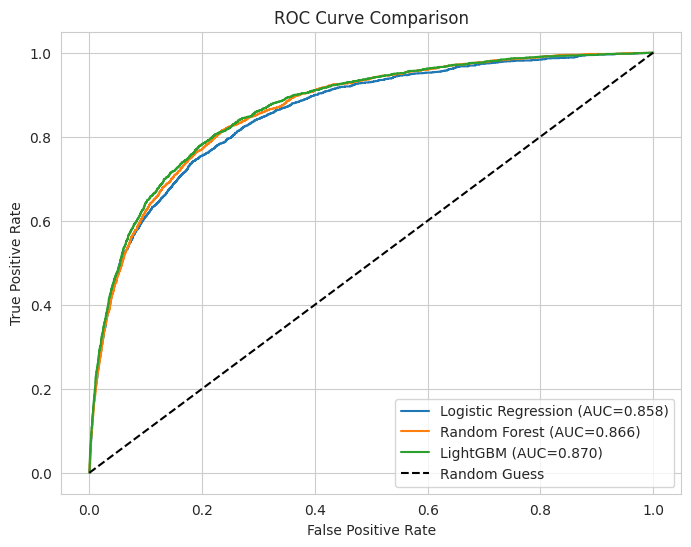

In [37]:
# Plot ROC curve buat ketiga model
plt.figure(figsize=(8, 6))
for name, proba in [('Logistic Regression', y_pred_proba_lr),
                     ('Random Forest', y_pred_proba_rf),
                     ('LightGBM', y_pred_proba_lgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

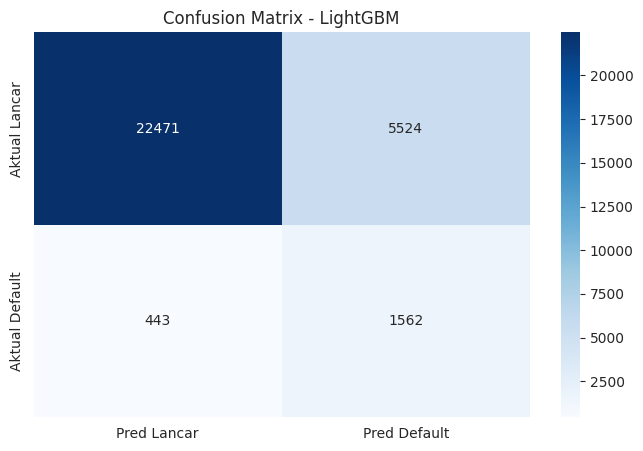

              precision    recall  f1-score   support

      Lancar       0.98      0.80      0.88     27995
     Default       0.22      0.78      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.85     30000



In [38]:
threshold = 0.5
y_pred_lgb = (y_pred_proba_lgb >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Lancar', 'Pred Default'],
            yticklabels=['Aktual Lancar', 'Aktual Default'])
plt.title('Confusion Matrix - LightGBM')
plt.show()
print(classification_report(y_test, y_pred_lgb, target_names=['Lancar', 'Default']))

## Step 8: Explainability (SHAP)

In [39]:
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# Kalau output-nya list (untuk binary classification kadang ke-return 2 array), ambil class 1
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


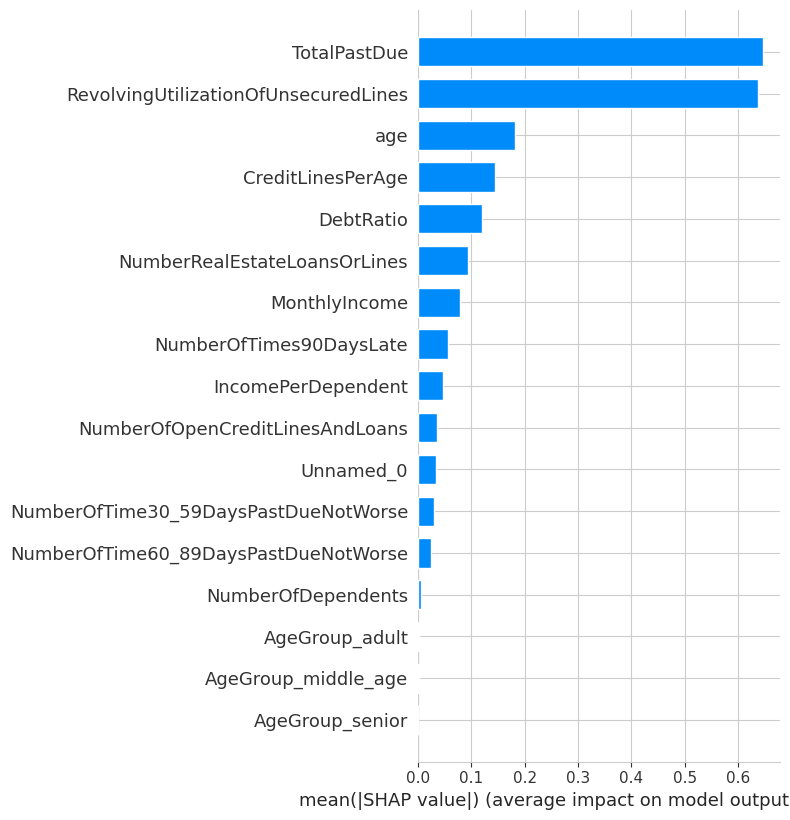

In [40]:
shap.summary_plot(shap_values_plot, X_test, plot_type='bar', show=True)

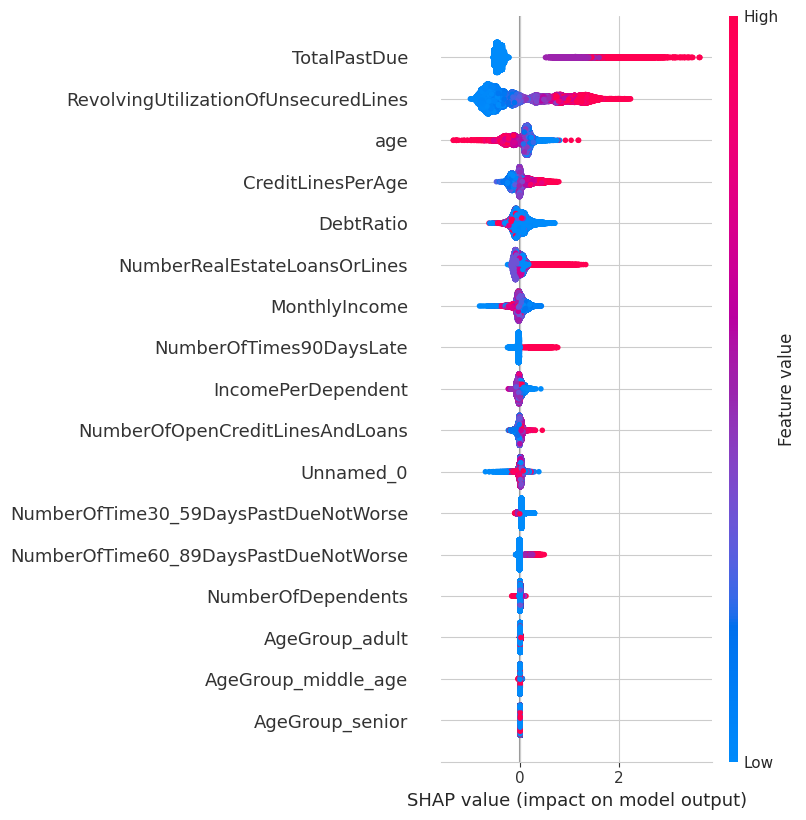

In [41]:
shap.summary_plot(shap_values_plot, X_test, show=True)

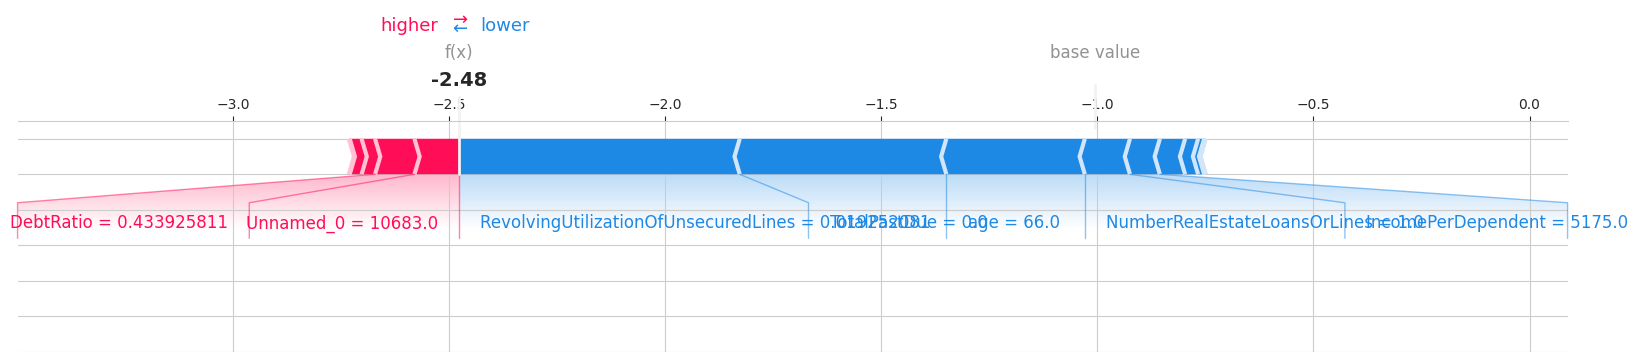


Probabilitas default applicant #0: 7.75%


In [42]:
# Individual explanation -> kenapa satu applicant tertentu dikasih skor segini
idx = 0  # ganti index ini buat lihat applicant lain

shap.force_plot(
    explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
    shap_values_plot[idx, :],
    X_test.iloc[idx, :],
    matplotlib=True,
    show=True
)

print(f"\nProbabilitas default applicant #{idx}: {y_pred_proba_lgb[idx]:.2%}")

In [44]:
import joblib
# Simpan model
joblib.dump(lgb_model, 'credit_scoring_lgb_model.pkl')
# Simpan juga scaler (kalau nanti dipake buat Logistic Regression atau preprocessing lain)
joblib.dump(scaler, 'scaler.pkl')
print("Model berhasil disimpan!")

Model berhasil disimpan!


In [45]:
from google.colab import files
files.download('credit_scoring_lgb_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>